In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading

In [2]:
df = pd.read_csv("../data/raw/accidents.csv")

In [3]:
df.head()

,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


Data Cleaning

In [4]:
df.shape

(1504150, 33)

In [5]:
df.columns

Index(['Unnamed: 0', 'Accident_Index', 'Location_Easting_OSGR',
       'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force',
       'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties',
       'Date', 'Day_of_Week', 'Time', 'Local_Authority_(District)',
       'Local_Authority_(Highway)', '1st_Road_Class', '1st_Road_Number',
       'Road_Type', 'Speed_limit', 'Junction_Control', '2nd_Road_Class',
       '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location', 'Year'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1504150 entries, 0 to 1504149
Data columns (total 33 columns):
 #   Column                                       Non-Null Count    Dtype  
---  ------                                       --------------    -----  
 0   Unnamed: 0                                   1504150 non-null  int64  
 1   Accident_Index                               1504150 non-null  object 
 2   Location_Easting_OSGR                        1504049 non-null  float64
 3   Location_Northing_OSGR                       1504150 non-null  float64
 4   Longitude                                    1504049 non-null  float64
 5   Latitude                                     1504150 non-null  float64
 6   Police_Force                                 1504150 non-null  int64  
 7   Accident_Severity                            1504150 non-null  int64  
 8   Number_of_Vehicles                           1504150 non-null  int64  
 9   Number_of_Casualties                         1

In [7]:
df.isnull().sum()

Unnamed: 0                                           0
Accident_Index                                       0
Location_Easting_OSGR                              101
Location_Northing_OSGR                               0
Longitude                                          101
Latitude                                             0
Police_Force                                         0
Accident_Severity                                    0
Number_of_Vehicles                                   0
Number_of_Casualties                                 0
Date                                                 0
Day_of_Week                                          0
Time                                               117
Local_Authority_(District)                           0
Local_Authority_(Highway)                            0
1st_Road_Class                                       0
1st_Road_Number                                      0
Road_Type                                            0
Speed_limi

In [8]:
df.describe()

,Unnamed: 0,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Speed_limit,2nd_Road_Class,2nd_Road_Number,Urban_or_Rural_Area,Year
count,1.504150e+06,1.504049e+06,1.504150e+06,1.504049e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06
mean,2.530433e+05,4.396214e+05,3.001382e+05,-1.436625e+00,5.258587e+01,3.020536e+01,2.838190e+00,1.831606e+00,1.350960e+00,4.118607e+00,3.476149e+02,4.087999e+00,1.009919e+03,3.900540e+01,2.675084e+00,3.815684e+02,1.353871e+00,2.009370e+03
std,1.489162e+05,9.511616e+04,1.610218e+05,1.398078e+00,1.512524e+00,2.551603e+01,4.018423e-01,7.147586e-01,8.253345e-01,1.924405e+00,2.594292e+02,1.428936e+00,1.823518e+03,1.413993e+01,3.205539e+00,1.302555e+03,4.783534e-01,3.013497e+00
min,0.000000e+00,6.495000e+04,0.000000e+00,-7.516225e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.000000e+00,1.000000e+01,-1.000000e+00,-1.000000e+00,1.000000e+00,2.005000e+03
25%,1.253452e+05,3.750600e+05,1.782600e+05,-2.373902e+00,5.149009e+01,6.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.100000e+02,3.000000e+00,0.000000e+00,3.000000e+01,-1.000000e+00,0.000000e+00,1.000000e+00,2.006000e+03
50%,2.506910e+05,4.399600e+05,2.688000e+05,-1.403714e+00,5.230888e+01,3.000000e+01,3.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,3.220000e+02,4.000000e+00,1.290000e+02,3.000000e+01,3.000000e+00,0.000000e+00,1.000000e+00,2.010000e+03
75%,3.760370e+05,5.230600e+05,3.981500e+05,-2.215100e-01,5.347855e+01,4.500000e+01,3.000000e+00,2.000000e+00,1.000000e+00,6.000000e+00,5.180000e+02,6.000000e+00,7.250000e+02,5.000000e+01,6.000000e+00,0.000000e+00,2.000000e+00,2.012000e+03
max,5.700100e+05,6.553700e+05,1.208800e+06,1.759398e+00,6.075754e+01,9.800000e+01,3.000000e+00,6.700000e+01,9.300000e+01,7.000000e+00,9.410000e+02,6.000000e+00,9.999000e+03,7.000000e+01,6.000000e+00,9.999000e+03,3.000000e+00,2.014000e+03


In [9]:
df["Accident_Severity"].value_counts()

Accident_Severity
3    1280205
2     204504
1      19441
Name: count, dtype: int64

In [10]:
df = df.drop(columns=["Unnamed: 0"])

In [11]:
df.columns

Index(['Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR',
       'Longitude', 'Latitude', 'Police_Force', 'Accident_Severity',
       'Number_of_Vehicles', 'Number_of_Casualties', 'Date', 'Day_of_Week',
       'Time', 'Local_Authority_(District)', 'Local_Authority_(Highway)',
       '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit',
       'Junction_Control', '2nd_Road_Class', '2nd_Road_Number',
       'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location', 'Year'],
      dtype='object')

In [12]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

In [13]:
df["Date"].head()

0   2005-01-04
1   2005-01-05
2   2005-01-06
3   2005-01-07
4   2005-01-10
Name: Date, dtype: datetime64[ns]

Exploratory Data Analysis

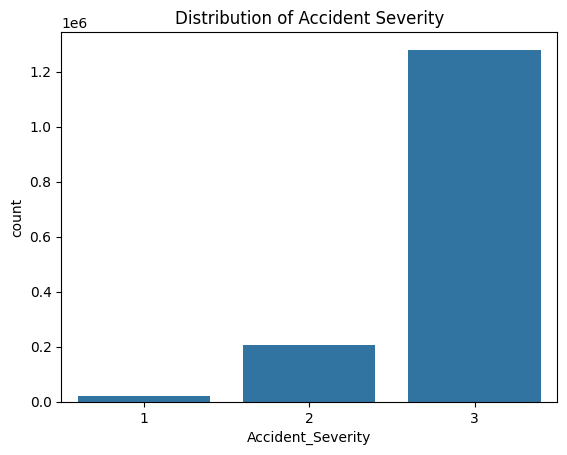

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Accident_Severity", data=df)
plt.title("Distribution of Accident Severity")
plt.show()

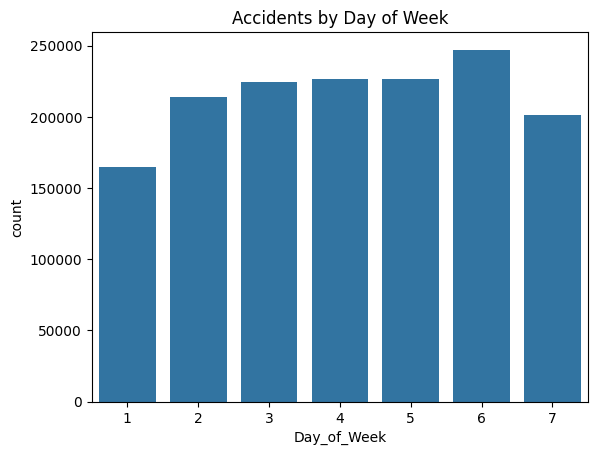

In [15]:
sns.countplot(x="Day_of_Week", data=df)
plt.title("Accidents by Day of Week")
plt.show()

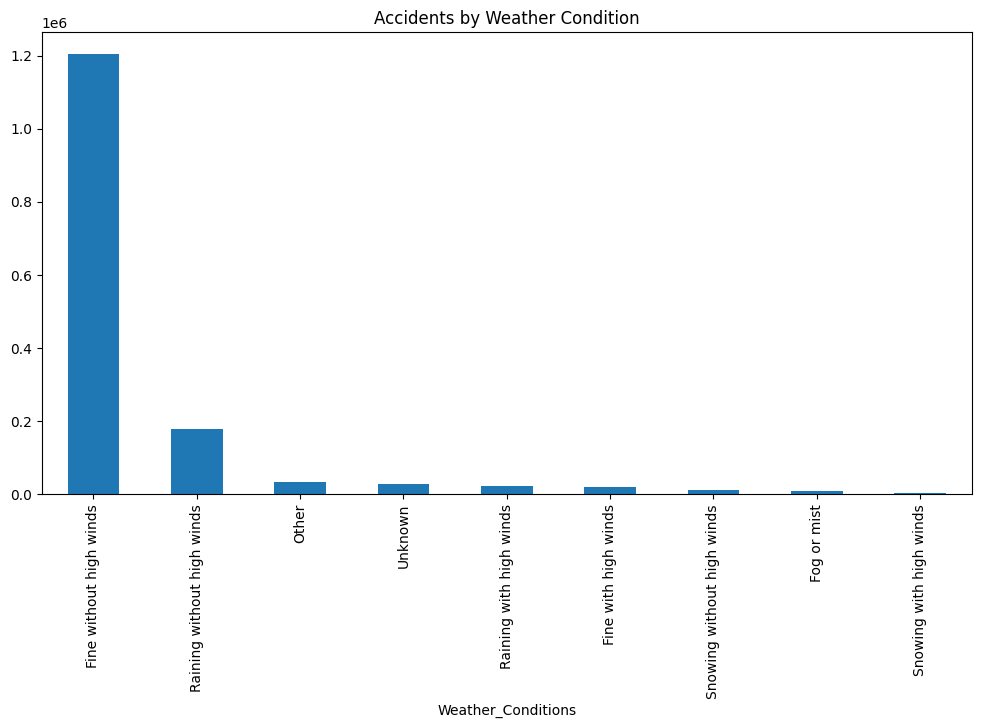

In [16]:
plt.figure(figsize=(12,6))
df["Weather_Conditions"].value_counts().plot(kind="bar")
plt.title("Accidents by Weather Condition")
plt.show()

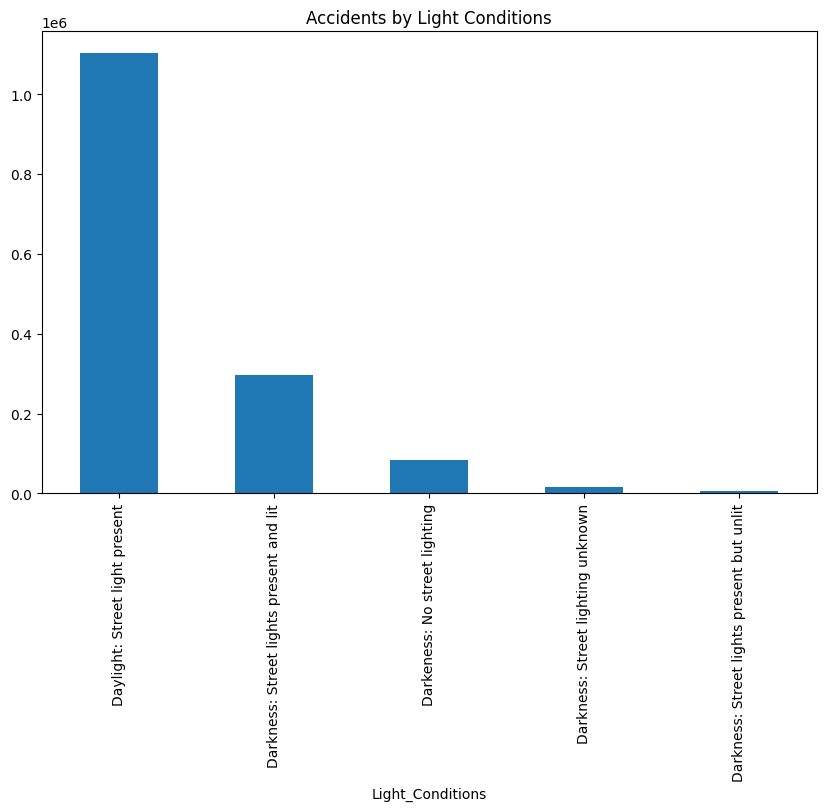

In [17]:
plt.figure(figsize=(10,6))
df["Light_Conditions"].value_counts().plot(kind="bar")
plt.title("Accidents by Light Conditions")
plt.show()

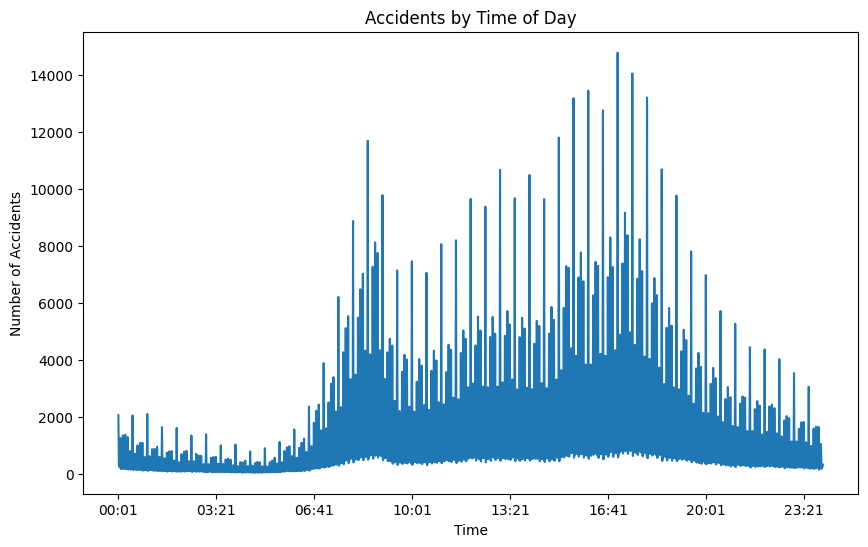

In [18]:
plt.figure(figsize=(10,6))
df["Time"].value_counts().sort_index().plot()
plt.title("Accidents by Time of Day")
plt.xlabel("Time")
plt.ylabel("Number of Accidents")
plt.show()

In [19]:
df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M").dt.hour

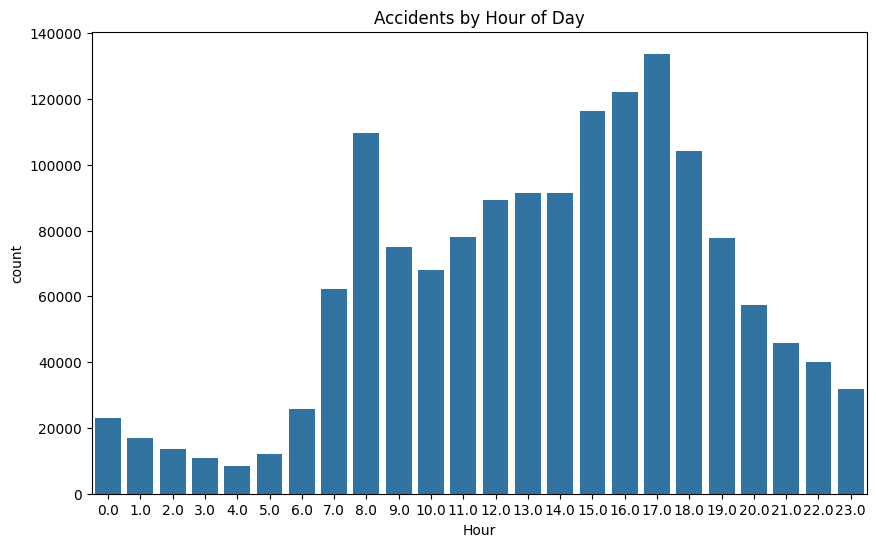

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(x="Hour", data=df)
plt.title("Accidents by Hour of Day")
plt.show()

Applying Feature Engineering

In [21]:
df["Rush_Hour"] = df["Hour"].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0)

1 - rush hour
0 - normal traffic

In [22]:
df["Night"] = df["Hour"].apply(lambda x: 1 if (x >= 20 or x <= 5) else 0)

1 = night driving
0 = daytime

In [23]:
df["Weekend"] = df["Day_of_Week"].apply(lambda x: 1 if x in [1,7] else 0)

1 = Saturday/Sunday
0 = weekday

In [24]:
df[["Hour","Rush_Hour","Night","Weekend"]].head()

,Hour,Rush_Hour,Night,Weekend
0,17.0,1,0,0
1,17.0,1,0,0
2,0.0,0,1,0
3,10.0,0,0,0
4,21.0,0,1,0


In [25]:
df[["Latitude","Longitude"]].describe()

,Latitude,Longitude
count,1.504150e+06,1.504049e+06
mean,5.258587e+01,-1.436625e+00
std,1.512524e+00,1.398078e+00
min,0.000000e+00,-7.516225e+00
25%,5.149009e+01,-2.373902e+00
50%,5.230888e+01,-1.403714e+00
75%,5.347855e+01,-2.215100e-01
max,6.075754e+01,1.759398e+00


In [26]:
df = df[(df["Latitude"] != 0) & (df["Longitude"] != 0)]

In [27]:
df[["Latitude","Longitude"]].describe()

,Latitude,Longitude
count,1.504049e+06,1.504049e+06
mean,5.258940e+01,-1.436625e+00
std,1.449889e+00,1.398078e+00
min,4.991294e+01,-7.516225e+00
25%,5.149016e+01,-2.373902e+00
50%,5.230913e+01,-1.403714e+00
75%,5.347858e+01,-2.215100e-01
max,6.075754e+01,1.759398e+00


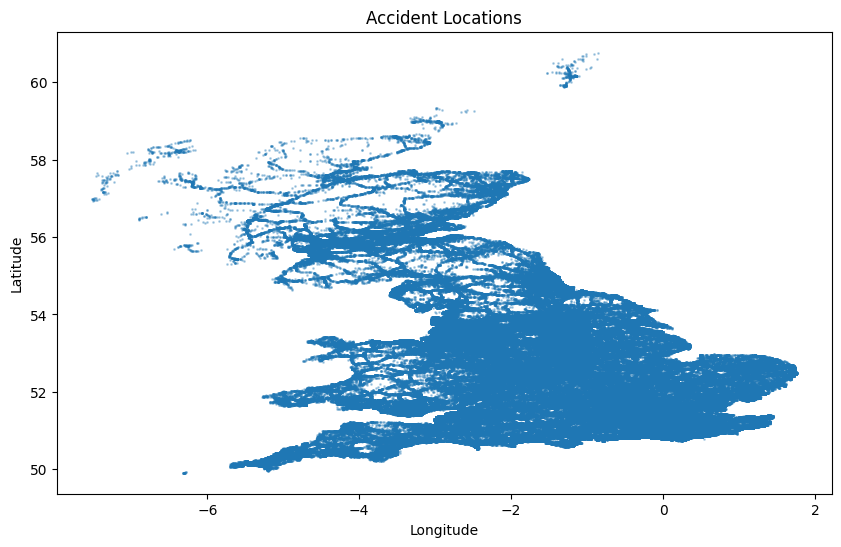

In [28]:
plt.figure(figsize=(10,6))
plt.scatter(df["Longitude"], df["Latitude"], s=1, alpha=0.3)
plt.title("Accident Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [29]:
from sklearn.cluster import DBSCAN
import numpy as np

coords = df[["Latitude", "Longitude"]].values

In [30]:
sample = df.sample(100000, random_state=42)
coords_sample = sample[["Latitude","Longitude"]].values

db = DBSCAN(eps=0.01, min_samples=50)
sample["cluster"] = db.fit_predict(coords_sample)

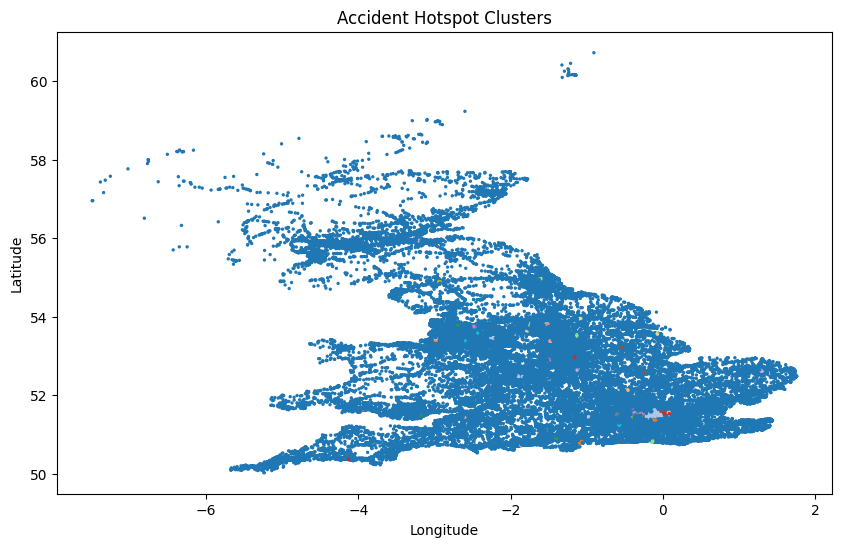

In [31]:
plt.figure(figsize=(10,6))
plt.scatter(sample["Longitude"], sample["Latitude"], 
            c=sample["cluster"], cmap="tab20", s=2)
plt.title("Accident Hotspot Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [32]:
sample["cluster"].value_counts().head(10)

cluster
-1     84148
 3      6905
 4       540
 19      433
 7       351
 5       348
 37      310
 16      292
 29      288
 22      266
Name: count, dtype: int64

In [33]:
sample["cluster"].nunique()

65

In [34]:
hotspots = sample[sample["cluster"] != -1]

centers = hotspots.groupby("cluster")[["Latitude","Longitude"]].mean()

centers.head()

,Latitude,Longitude
cluster,,
0,53.815949,-3.047214
1,55.860474,-4.260391
2,51.568994,-0.222902
3,51.509943,-0.117514
4,52.473092,-1.885728


In [35]:
import sys
!{sys.executable} -m pip install folium

In [36]:
import folium
from folium.plugins import HeatMap

heat_data = sample[['Latitude', 'Longitude']].values.tolist()

m = folium.Map(location=[52.5, -1.5], zoom_start=6)

HeatMap(heat_data, radius=8).add_to(m)

m.save("accident_hotspots.html")

In [37]:
sample[['Hour','Rush_Hour','Night','Weekend']].head()

,Hour,Rush_Hour,Night,Weekend
569528,9.0,1,0,1
566522,15.0,0,0,0
1475193,16.0,1,0,1
512722,15.0,0,0,0
103297,9.0,1,0,1


In [41]:
print(sample['Rush_Hour'].value_counts())
print(sample['Night'].value_counts())
sample['Weekend'].value_counts()

Rush_Hour
0    59776
1    40224
Name: count, dtype: int64
Night
0    82873
1    17127
Name: count, dtype: int64


Weekend
0    75675
1    24325
Name: count, dtype: int64

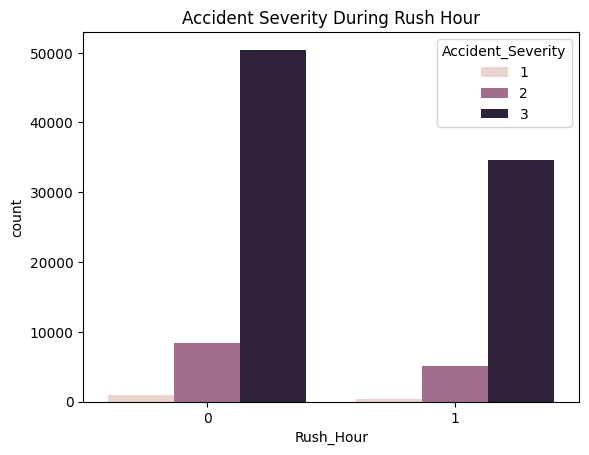

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Rush_Hour", hue="Accident_Severity", data=sample)

plt.title("Accident Severity During Rush Hour")
plt.show()

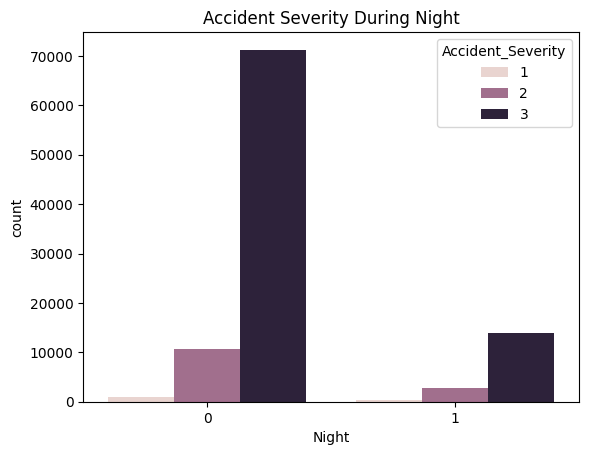

In [43]:
sns.countplot(x="Night", hue="Accident_Severity", data=sample)

plt.title("Accident Severity During Night")
plt.show()

In [44]:
severity_rush = pd.crosstab(
    sample["Rush_Hour"],
    sample["Accident_Severity"],
    normalize="index"
) * 100

severity_rush

Accident_Severity,1,2,3
Rush_Hour,,,
0,1.493911,14.116033,84.390056
1,1.029236,12.736177,86.234586


Rush hour increases accident frequency
but reduces accident severity.

In [46]:
severity_night = pd.crosstab(
    sample["Night"],
    sample["Accident_Severity"],
    normalize="index"
) * 100

severity_night

Accident_Severity,1,2,3
Night,,,
0,1.108926,12.912529,85.978545
1,2.265429,16.698780,81.035791


Night driving significantly increases accident severity.

Analysis shows that rush hour increases accident frequency but decreases severity due to lower vehicle speeds. In contrast, night-time driving significantly increases the proportion of fatal and serious accidents, likely due to reduced visibility and higher travel speeds.

In [47]:
df = sample.copy()
df = df.drop(columns=[
    "Accident_Index",
    "LSOA_of_Accident_Location",
    "Date"
], errors="ignore")

df.head()

,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Time,...,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Hour,Rush_Hour,Night,Weekend,cluster
569528,235420.0,626690.0,-4.607583,55.506211,97,3,1,1,1,09:15,...,NaN,NaN,1,Yes,2007,9.0,1,0,1,-1
566522,241800.0,661940.0,-4.526990,55.824748,97,3,1,1,3,15:50,...,NaN,NaN,1,Yes,2007,15.0,0,0,0,-1
1475193,506982.0,124420.0,-0.476449,51.009162,47,2,3,2,7,16:30,...,NaN,NaN,2,Yes,2014,16.0,1,0,1,-1
512722,468510.0,107700.0,-1.027868,50.864691,44,3,2,1,3,15:20,...,NaN,NaN,1,Yes,2007,15.0,0,0,0,-1
103297,501190.0,342980.0,-0.494491,52.974608,32,3,1,1,7,09:25,...,NaN,NaN,2,Yes,2005,9.0,1,0,1,-1


In [48]:
X = df.drop("Accident_Severity", axis=1)
y = df["Accident_Severity"]

In [49]:
X.select_dtypes(include="object").columns

Index(['Time', 'Local_Authority_(Highway)', 'Road_Type', 'Junction_Control',
       'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Did_Police_Officer_Attend_Scene_of_Accident'],
      dtype='object')

In [50]:
df = df.drop(columns=["Time", "Local_Authority_(Highway)"], errors="ignore")

In [51]:
categorical_cols = [
'Road_Type',
'Junction_Control',
'Pedestrian_Crossing-Human_Control',
'Pedestrian_Crossing-Physical_Facilities',
'Light_Conditions',
'Weather_Conditions',
'Road_Surface_Conditions',
'Special_Conditions_at_Site',
'Carriageway_Hazards',
'Did_Police_Officer_Attend_Scene_of_Accident'
]

One Hot Encoding

In [52]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [53]:
X = df_encoded.drop("Accident_Severity", axis=1)
y = df_encoded["Accident_Severity"]

In [54]:
df_encoded.shape

(100000, 65)

In [55]:
X.shape

(100000, 64)

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
y_pred = model.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8539

Confusion Matrix:
[[    0     0   261]
 [    0     0  2660]
 [    0     1 17078]]

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       261
           2       0.00      0.00      0.00      2660
           3       0.85      1.00      0.92     17079

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.79     20000



c:\Users\goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Class imbalance occured as majority cases are of severity 3, so model is mostly predicting severity 3.

In [60]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7798
[[   43    64   154]
 [  148   599  1913]
 [  390  1735 14954]]
              precision    recall  f1-score   support

           1       0.07      0.16      0.10       261
           2       0.25      0.23      0.24      2660
           3       0.88      0.88      0.88     17079

    accuracy                           0.78     20000
   macro avg       0.40      0.42      0.41     20000
weighted avg       0.78      0.78      0.78     20000



In [62]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

importance.head(15)

,Feature,Importance
2,Longitude,0.069730
0,Location_Easting_OSGR,0.069476
1,Location_Northing_OSGR,0.068906
3,Latitude,0.068755
8,Local_Authority_(District),0.060539
10,1st_Road_Number,0.057769
16,Hour,0.056564
11,Speed_limit,0.049111
15,Year,0.042942
5,Number_of_Vehicles,0.042454


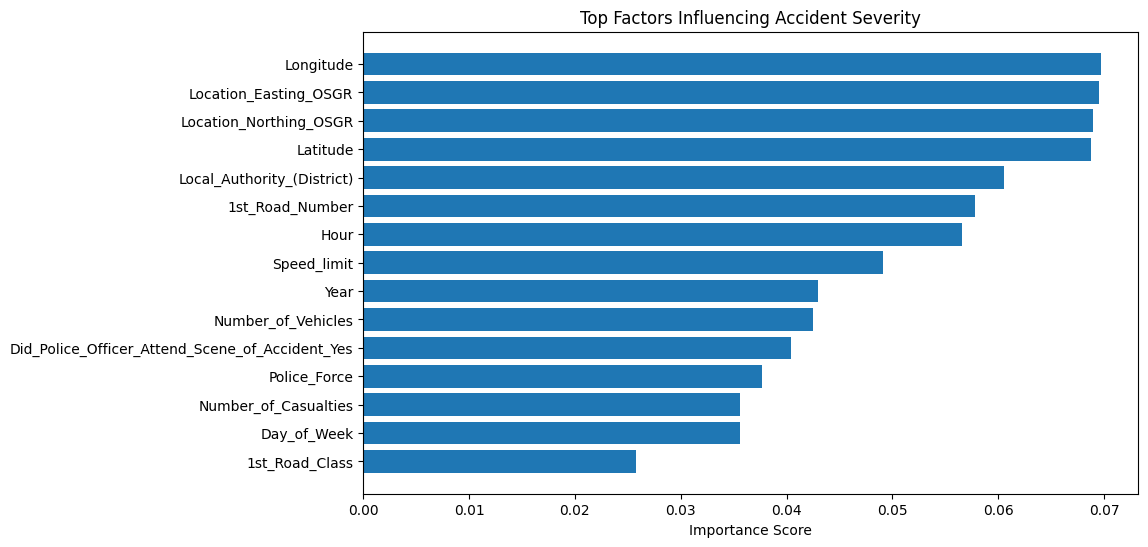

In [63]:
top_features = importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Factors Influencing Accident Severity")
plt.xlabel("Importance Score")
plt.show()